# Synthetic Example

Toy 2D example illustrating CDVM data selection on a small synthetic dataset.
Compares LOO, Shapley, Banzhaf, and CDVM selection on a two-class problem.

**Input:** None (self-contained)  
**Output:** `output/` (2D decision boundary plots)

In [ ]:
import math
import numpy as np
import matplotlib.pyplot as plt

from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier


## Helper functions

In [ ]:
def data_shapley_accuracy(idx_lis, predictions, y_, debug_print=False):
  """Compute the data shapley value from predictions.

  Args:
    idx_lis: List of indices of training points used at step i, shape: (2^(n-1), -1).
    predictions: List of test predictions for each set of indices, shape: (2^(n-1), n_test_points).

  Returns:

  """
  n_points = len(idx_lis[-1])

  values = []
  for i in range(n_points):
    point_i_active = [j for j in range(len(idx_lis)) if i in idx_lis[j]]
    value_i = 0

    for j in point_i_active:
      idx_wo_i = list(idx_lis[j])
      idx_wo_i.remove(i)
      idx_wo_i = set(idx_wo_i)
      acc_1 = np.mean(predictions[j]==y_)

      if len(idx_wo_i) > 0:
        for k in range(len(idx_lis)):
          if set(idx_lis[k]) == idx_wo_i:

            acc_2 = np.mean(predictions[k]==y_)

            if debug_print:
              print(f"Point {i}", idx_lis[k], idx_wo_i, predictions[k],
                    predictions[j], acc_1-acc_2, n_points-1,
                    len(idx_wo_i), math.comb(n_points-1, len(idx_wo_i)))
              print()

            value_i += (acc_1-acc_2) / math.comb(n_points-1, len(idx_wo_i))

      else:
        value_i += acc_1 / math.comb(n_points-1, len(idx_wo_i))
        if debug_print:
          print(f"Point {i}", idx_wo_i,
                predictions[j], - acc_1, n_points-1,
                len(idx_wo_i), math.comb(n_points-1, len(idx_wo_i)))
          print()

    values.append(value_i)

  return np.array(values) / n_points

In [ ]:
def data_banzhaf_accuracy(idx_lis, predictions, y_, debug_print=True):
  """Compute the data Banzhaf value from predictions.

  Args:
    idx_lis: List of indices of training points used at step i, shape: (2^n, -1).
    predictions: List of test predictions for each set of indices, shape: (2^n, n_test_points).
    y_: True labels.

  Returns:
    Banzhaf values for each data point.
  """
  n_points = len(idx_lis[-1])

  values = []
  for i in range(n_points):
    point_i_active = [j for j in range(len(idx_lis)) if i in idx_lis[j]]
    value_i = 0

    for j in point_i_active:
      idx_wo_i = list(idx_lis[j])
      idx_wo_i.remove(i)
      idx_wo_i = set(idx_wo_i)
      acc_1 = np.mean(predictions[j] == y_)

      if len(idx_wo_i) > 0:
        for k in range(len(idx_lis)):
          if set(idx_lis[k]) == idx_wo_i:
            acc_2 = np.mean(predictions[k] == y_)

            if debug_print:
              print(f"Point {i}", idx_lis[k], idx_wo_i, predictions[k],
                    predictions[j], acc_1 - acc_2, n_points - 1,
                    len(idx_wo_i))
              print()

            value_i += (acc_1 - acc_2)  # kein comb-Gewicht

      else:
        value_i += acc_1
        if debug_print:
          print(f"Point {i}", idx_wo_i,
                predictions[j], acc_1, n_points - 1,
                len(idx_wo_i))
          print()

    values.append(value_i)

  return np.array(values) / 2**(n_points - 1)  # Banzhaf-Normalisierung

In [ ]:
def get_decision_boundary(predict_func, x_lim, y_lim, num_points=500):
    """Return triple representing the decision boundary generated by 'model'.

    Args:
        predict_func (function): The classifiers prediction function, e.g. model.predict.
        num_points (int): Number of points used for mesh grid.

    Returns:
        xx, yy, Z (numpy.ndarray, numpy.ndarray, numpy.ndarray): The decision boundary.
            2D arrays of shape [num_points x num_points]. xx and yy is the meshgrid and
            Z predictions for the meshgrid reshaped to shape of xx.
    """

    x1_min, x1_max = x_lim
    x2_min, x2_max = y_lim

    x1_step = (x1_max - x1_min) / num_points
    x2_step = (x2_max - x2_min) / num_points

    xx, yy = np.meshgrid(np.arange(x1_min, x1_max, x1_step),
                          np.arange(x2_min, x2_max, x2_step))

    mesh = np.c_[xx.ravel(), yy.ravel()]

    Z = predict_func(mesh)  # noqa
    Z = Z.reshape(xx.shape)  # noqa

    return xx, yy, Z

In [ ]:
def scatter(X_, y_, plot_db=False, pred_func=None,
            title="", X_grey=None, y_grey=None, s=None,
            num_points=500, xlim=[-3, 3], ylim=[-3, 3], ax=None, save_name=""):
  """"""

  ax_ = ax if ax is not None else plt.subplots()[1]

  mask_0 = y_ == 0
  mask_1 = y_ == 1

  if X_grey is not None:
    if len(X_grey.shape) == 1:
      marker = '^' if y_grey == 1 else 'o'
      s_ = 80 if y_grey == 1 else 40
      plt.scatter(X_grey[0], X_grey[1], color="grey",   s=s_, marker=marker)

    else:
      mask_grey_0 = y_grey == 0
      mask_gery_1 = y_grey == 1

      ax_.scatter(X_grey[mask_grey_0, 0], X_grey[mask_grey_0, 1], color="grey",  marker="o")
      ax_.scatter(X_grey[mask_gery_1, 0], X_grey[mask_gery_1, 1], color="grey",  marker="^")

  if s is not None:
    ax_.scatter(X_[mask_0, 0], X_[mask_0, 1], label="0", s=s[mask_0], marker='o', c='blue', alpha=0.5)
    ax_.scatter(X_[mask_1, 0], X_[mask_1, 1], label="1", s=s[mask_1], marker= '^', c='red', alpha=0.5)
  else:
    ax_.scatter(X_[mask_0, 0], X_[mask_0, 1], label="0", s=40, marker='o', c='blue', alpha=0.5)
    ax_.scatter(X_[mask_1, 0], X_[mask_1, 1], label="1", s=80, marker= '^', c='red', alpha=0.5)


  if plot_db:
    ax_.plot([-2, 1], [2, -1], c="black")

  if pred_func is not None:
    xx, yy, Z = get_decision_boundary(pred_func, xlim, ylim, num_points)
    CS = ax_.contour(xx, yy, Z, cmap="Greys")  # noqa

  ax_.axis('scaled')
  ax_.set_xlim(xlim)
  ax_.set_ylim(ylim)
  ax_.set_title(title)

  if save_name != "":
    plt.savefig(save_name)

  if ax is None:
    plt.show()

In [ ]:
def powerset_all(X__, y__, min_length=1):
    """Returns all powersets."""
    s = list(range(X__.shape[0]))
    x = len(s)
    masks = [1 << i for i in range(x)]

    for i in range(0, 1 << x):
      m_ = [ss for mask, ss in zip(masks, s) if i & mask]
      if len(m_)>=min_length:
          yield m_

In [ ]:
def compute_and_plot(X_train, y_train, X_test, y_test, method="Shapley"):

  mask, predictions = [], []

  # All combinations with at least one sample per class
  for m in powerset_all(X_train, y_train):
    clf = MLPClassifier(2500, max_iter=2000)
    x_ = X_train[m]
    y_ = y_train[m]
    clf.fit(x_, y_)
    # scatter(x_, y_, xlim=[-3, 3], ylim=[-3, 3], pred_func=clf.predict)
    mask.append(m)
    predictions.append(clf.predict(X_test))

  dv_func = data_shapley_accuracy if method == "Shapley" else data_banzhaf_accuracy
  dv = dv_func(mask, predictions, y_test)
  print(dv)
  scatter(X_train, y_train, xlim=[-3, 3], ylim=[-3, 3], pred_func=clf.predict, s=((np.array(dv)*50))**2)
  return mask, predictions

## Data

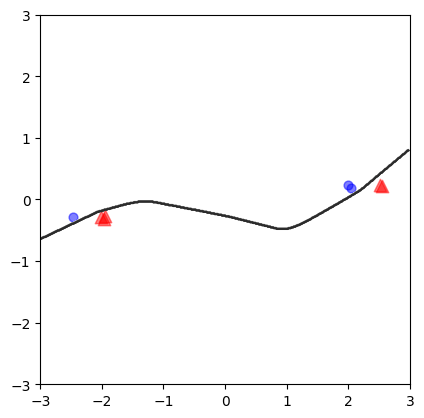

In [ ]:
np.random.seed(1)

X = np.array([[-2, -.25],
                [-2, -.25],
                [-2, -.25],
                #
                [2.5, .25],
                [2.5, .25],
                #
                [2, .25],
                [2, .25],
                #
                [-2.5, -.25]])

X += np.random.multivariate_normal([0, 0], [[0.001, 0], [0, 0.001]], X.shape[0])
y = np.array([1, 1, 1, 1, 1, 0, 0, 0])

clf = MLPClassifier(5000, max_iter=1000)
clf.fit(X, y)

scatter(X, y, pred_func=clf.predict)

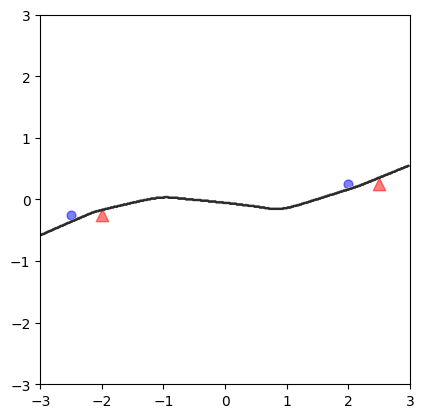

In [ ]:
np.random.seed(1)

X_2 = np.array([[-2, -.25], [2.5, .25],
                [2, .25], [-2.5, -.25]])

y_2 = np.array([1, 1, 0, 0])

clf = MLPClassifier(500, max_iter=1000)
clf.fit(X_2, y_2)

scatter(X_2, y_2, pred_func=clf.predict)

## Experiments

## LOO

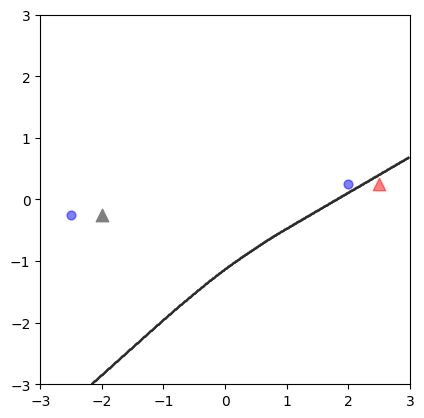

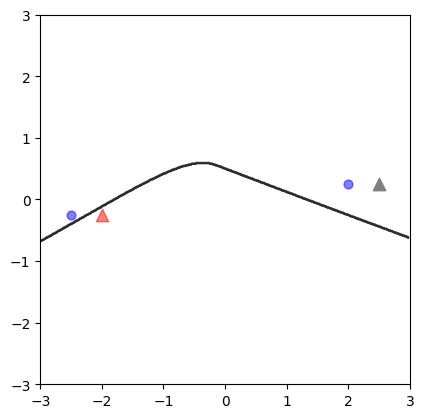

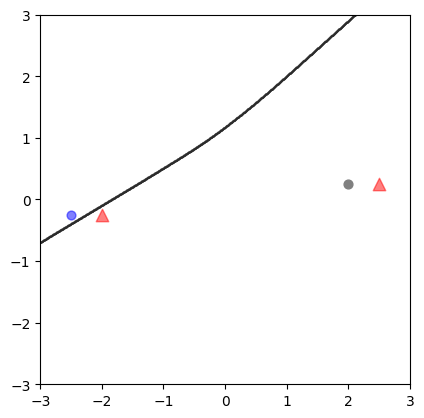

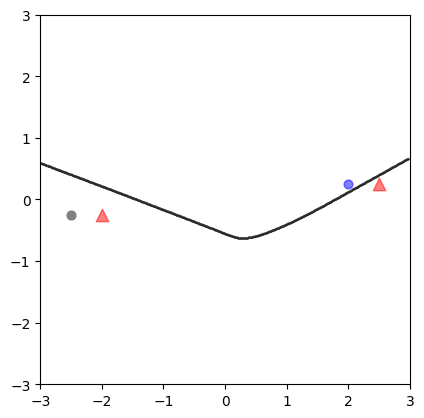

In [ ]:
for i in range(X_2.shape[0]):
  clf = MLPClassifier(500, max_iter=1000)
  x_ = np.delete(X_2, i, 0)
  y_ = np.delete(y_2, i)
  clf.fit(x_, y_)
  scatter(x_, y_, xlim=[-3, 3], ylim=[-3, 3],
          pred_func=clf.predict,
          X_grey=X_2[i], y_grey=y_2[i])

## Shapley

[0.08333333 0.08333333 0.08333333 0.125      0.125      0.125
 0.125      0.25      ]


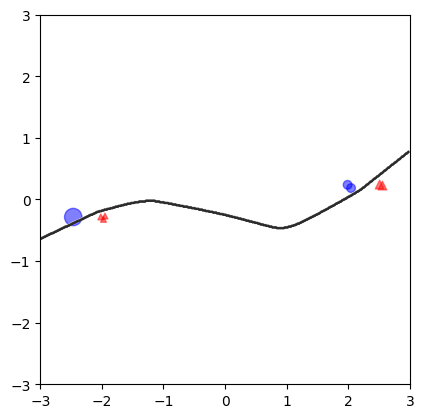

In [ ]:
mask, predictions = [], []

# All combinations with at least one sample per class
for m in powerset_all(X, y):
  clf = MLPClassifier(1000, max_iter=1000)
  x_ = X[m]
  y_ = y[m]
  clf.fit(x_, y_)
  # scatter(x_, y_, xlim=[-3, 3], ylim=[-3, 3], pred_func=clf.predict)
  mask.append(m)
  predictions.append(clf.predict(X_2))

dv = data_shapley_accuracy(mask, predictions, y_2)
print(dv)
scatter(X, y, xlim=[-3, 3], ylim=[-3, 3], pred_func=clf.predict, s=((np.array(dv)*50))**2)


## PyDVL

In [ ]:
!pip install pyDVL

In [ ]:
from pydvl.value import *

In [ ]:
model = MLPClassifier(1000, max_iter=1000)
data = Dataset(X, y, X_2, y_2)
u = Utility(model, data, Scorer("accuracy", default=0.0))

In [ ]:
values = compute_data_oob(u)
values

ValuationResult(algorithm='data_oob',status='pending',values=[1.     1.     1.     0.6667 0.6667 0.8    0.8    0.    ],indices=[0 1 2 3 4 5 6 7],names=[0 1 2 3 4 5 6 7],counts=[5 4 8 3 3 5 5 4])

In [ ]:
values = compute_shapley_values(u, mode="combinatorial_exact")
values

ValuationResult(algorithm='combinatorial_exact_shapley',status='converged',values=[0.0833 0.0744 0.0833 0.1161 0.125  0.125  0.1875 0.25  ],indices=[0 1 2 3 4 5 6 7],names=[0 1 2 3 4 5 6 7],counts=[1. 1. 1. 1. 1. 1. 1. 1.])

In [ ]:
values = compute_banzhaf_semivalues(u=u, done=MaxUpdates(1000))
values

/usr/local/lib/python3.10/dist-packages/pydvl/parallel/backends/joblib.py:87: UserWarning: Cancellation of futures is not supported by the joblib backend
  warnings.warn(


ValuationResult(algorithm='semivalue-PermutationSampler-banzhaf_coefficient',status='converged',values=[0.04   0.0294 0.0365 0.0953 0.0952 0.0907 0.1046 0.2267],indices=[0 1 2 3 4 5 6 7],names=[0 1 2 3 4 5 6 7],counts=[ 999  999  999  999  999  999 1000  999])